# Load packages

In [1]:
import scimap as sm
import scanpy as sc

import anndata as ad

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from scipy.stats import wilcoxon
import os

import numpy as np

Running SCIMAP  2.2.11


# Load data

In [6]:
adata = ad.read_h5ad('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/adata_interaction_radius45_imageid.h5ad')

# scimap spatial pscore

In [12]:
immune_celltypes = ['CD68.Macrophages', 'CD206.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg', 'Other.Immune']
Tumor_celltypes = ['Tumor.GCLC+VIM+', 'Tumor.GCLC+VIM-', 'Tumor.GCLC-VIM+']

In [ ]:
def calculate_pscore_for_celltypes(adata, score_by, x_coordinate, y_coordinate, phenotype, method, radius):
    """
    Calculate pscore for each combination of immune celltype and tumor celltype.
    
    Parameters:
    -----------
    adata : AnnData
        Annotated data matrix.
        
    Returns:
    --------
    adata : AnnData
        Updated annotated data matrix with pscore calculations.
    """
    for immune_type in immune_celltypes:
        for tumor_type in Tumor_celltypes:
            # Create a label for this combination
            # Replace special characters to avoid naming issues
            safe_immune_type = immune_type.replace('.', '_')
            safe_tumor_type = tumor_type.replace('.', '_').replace('+', 'pos').replace('-', 'neg')
            label = f"pscore_{safe_tumor_type}_{safe_immune_type}"
            
            # Calculate pscore
            adata = sm.tl.spatial_pscore(
                adata,
                proximity = [tumor_type, immune_type],
                score_by = score_by,
                x_coordinate = x_coordinate,
                y_coordinate = y_coordinate,
                phenotype = phenotype,
                method = method,
                radius = radius,
                label = label
            )
    
    return adata

In [ ]:
adata_pscore = calculate_pscore_for_celltypes(adata,
                                              score_by='core_imageid',
                                              x_coordinate='X_centroid', 
                                              y_coordinate='Y_centroid',
                                              phenotype='GCLC_VIM',
                                              method='radius',
                                              radius=45)
adata_pscore.write_h5ad('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/adata_interaction_radius45_imageid_pscore.h5ad')

# Correct values

In [2]:
adata_pscore = ad.read_h5ad('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/adata_interaction_radius45_imageid_pscore.h5ad')

In [8]:
adata_pscore.uns['pscore_Tumor_GCLCnegVIMpos_CD206_Macrophages']

,Tumor.GCLC-VIM+_CD206.Macrophages,All Cells,Proximity Volume,Celltype of interest,Proximity Density
core_imageid,,,,,
core1_1B,137,12018,0.011400,1137,0.030783
core1_2B,21,5100,0.004118,126,0.015873
core1_3B,441,11618,0.037958,1474,0.090231
core1_19_02_01A,0,7804,0.000000,39,0.000000
core1_19_02_03A,0,4811,0.000000,332,0.000000
...,...,...,...,...,...
core79_INF2,182,10829,0.016807,1334,0.029985
core80_19_02_01A,1,7461,0.000134,579,0.000000
core82_1B,13,706,0.018414,75,0.053333


In [32]:
pscore_list = ['pscore_Tumor_GCLCposVIMpos_CD68_Macrophages', 'pscore_Tumor_GCLCposVIMneg_CD68_Macrophages', 'pscore_Tumor_GCLCnegVIMpos_CD68_Macrophages',
 'pscore_Tumor_GCLCposVIMpos_CD206_Macrophages', 'pscore_Tumor_GCLCposVIMneg_CD206_Macrophages', 'pscore_Tumor_GCLCnegVIMpos_CD206_Macrophages',
 'pscore_Tumor_GCLCposVIMpos_CD4_T_cells', 'pscore_Tumor_GCLCposVIMneg_CD4_T_cells', 'pscore_Tumor_GCLCnegVIMpos_CD4_T_cells',
 'pscore_Tumor_GCLCposVIMpos_CD8_T_cells', 'pscore_Tumor_GCLCposVIMneg_CD8_T_cells', 'pscore_Tumor_GCLCnegVIMpos_CD8_T_cells',
 'pscore_Tumor_GCLCposVIMpos_Treg', 'pscore_Tumor_GCLCposVIMneg_Treg', 'pscore_Tumor_GCLCnegVIMpos_Treg',
 'pscore_Tumor_GCLCposVIMpos_Other_Immune', 'pscore_Tumor_GCLCposVIMneg_Other_Immune', 'pscore_Tumor_GCLCnegVIMpos_Other_Immune']

In [33]:

def calculate_proximity_metrics(adata_pscore, pscore_label):
    """
    Calculate proximity volume and density metrics for a given pscore label.
    
    Parameters:
    -----------
    adata_pscore : AnnData
        Annotated data matrix with proximity scores.
    pscore_label : str
        The proximity score label to process.
    
    Returns:
    --------
    proximity_score : DataFrame
        DataFrame containing the proximity metrics.
    """
    # Extract tumor status and cell type from the pscore label for filtering
    parts = pscore_label.split('_')
    tumor_status = parts[2]  # GCLC VIM status
    tumor_status = tumor_status.replace("pos", "+").replace("neg", "-")
    cell_type = '_'.join(parts[3:])  # The rest is the cell type
    
    # Convert to the format used in GCLC_VIM
    tumor = f"Tumor.{tumor_status}"
    cell_type_converted = cell_type.replace('_', '.')
    
    # Get the whole dataset
    wh_d = adata_pscore.obs.copy()
    whole_data = wh_d[['core_imageid', pscore_label, 'GCLC_VIM']]

    # Calculate proximity volume
    p_v = whole_data.groupby(['core_imageid', pscore_label], observed=False).size().unstack().fillna(0)
    
    # Find the interaction column - it should be the one that's not 'other'
    interaction_cols = [col for col in p_v.columns if col != 'other']
    if not interaction_cols:
        print(f"No interaction column found for {pscore_label}")
        return pd.DataFrame()
    
    interaction_col = interaction_cols[0]
    
    p_v['All Cells'] = p_v[interaction_col] + p_v.get("other", 0)
    p_v['Proximity Volume'] = p_v[interaction_col] / p_v['All Cells']
    p_v = p_v.fillna(0)  # replace NA
    p_v = p_v.replace([np.inf, -np.inf], 0)
    p_v = p_v.drop(columns='other', errors='ignore')
    
    # Filter for relevant cell types for proximity density
    w_d = whole_data[whole_data['GCLC_VIM'].isin([tumor, cell_type_converted])]
    p_d = w_d.groupby(['core_imageid', pscore_label], observed=False).size().unstack().fillna(0)
    
    # Find the interaction column in p_d
    interaction_cols_d = [col for col in p_d.columns if col != 'other']
    if not interaction_cols_d:
        print(f"No interaction column found in filtered data for {pscore_label}")
        return pd.DataFrame()
    
    interaction_col_d = interaction_cols_d[0]
    
    p_d['Celltype of interest'] = p_d[interaction_col_d] + p_d.get("other", 0)
    p_d['Proximity Density'] = p_d[interaction_col_d] / p_d['Celltype of interest']
    p_d = p_d.fillna(0)  # replace NA
    p_d = p_d.replace([np.inf, -np.inf], 0)
    p_d = p_d.drop(columns=[col for col in p_d.columns if col not in ['Celltype of interest', 'Proximity Density']])
    
    # Merge the results
    proximity_score = pd.merge(p_v, p_d, left_index=True, right_index=True)
    
    return proximity_score

# Process each pscore
for pscore in pscore_list:
    try:
        # Calculate proximity metrics
        proximity_score = calculate_proximity_metrics(adata_pscore, pscore)
        
        if not proximity_score.empty:
            # Store in adata_pscore.uns
            adata_pscore.uns[pscore] = proximity_score
    
    except Exception as e:
        print(f"Error processing {pscore}: {e}")
        


In [35]:
adata_pscore.uns['pscore_Tumor_GCLCnegVIMpos_CD206_Macrophages']

pscore_Tumor_GCLCnegVIMpos_CD206_Macrophages,Tumor.GCLC-VIM+_CD206.Macrophages,All Cells,Proximity Volume,Celltype of interest,Proximity Density
core_imageid,,,,,
core1_1B,70,12018,0.005825,1137,0.061566
core1_2B,6,5100,0.001176,126,0.047619
core1_3B,413,11618,0.035548,1474,0.280190
core1_19_02_01A,0,7804,0.000000,39,0.000000
core1_19_02_03A,0,4811,0.000000,332,0.000000
...,...,...,...,...,...
core79_INF2,118,10829,0.010897,1334,0.088456
core80_19_02_01A,3,7461,0.000402,579,0.005181
core82_1B,8,706,0.011331,75,0.106667


# Save csv file

In [37]:
# Initialize an empty DataFrame to store the results
result_df = pd.DataFrame()

# Process each pscore
for pscore in pscore_list:
    # Extract the data from adata_pscore.uns
    if pscore in adata_pscore.uns:
        pscore_data = adata_pscore.uns[pscore]
        
        # Ensure 'core_imageid' is a column, not an index
        pscore_data = pscore_data.reset_index()
        # Extract core_imageid and Proximity Density
        temp_df = pscore_data[['core_imageid', 'Proximity Density']].copy()
        
        # Convert column name format from pscore_Tumor_GCLCposVIMpos_CD68_Macrophages 
        # to Tumor.GCLC+VIM+_CD68.Macrophages
        column_name = pscore.replace('pscore_', '')
        column_name = column_name.replace('Tumor_GCLCposVIMpos', 'Tumor.GCLC+VIM+')
        column_name = column_name.replace('Tumor_GCLCposVIMneg', 'Tumor.GCLC+VIM-')
        column_name = column_name.replace('Tumor_GCLCnegVIMpos', 'Tumor.GCLC-VIM+')
        column_name = column_name.replace('_', '.', 1)  # Replace only first underscore
        
        # Rename the column
        temp_df.rename(columns={'Proximity Density': column_name}, inplace=True)
        
        # Merge with the result DataFrame
        if result_df.empty:
            result_df = temp_df
        else:
            result_df = pd.merge(result_df, temp_df, on='core_imageid', how='outer')

# Save to CSV
result_df.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/proximity_density_scores.csv', index=False)

In [36]:
# Initialize an empty DataFrame to store the results
result_df = pd.DataFrame()

# Process each pscore
for pscore in pscore_list:
    # Extract the data from adata_pscore.uns
    if pscore in adata_pscore.uns:
        pscore_data = adata_pscore.uns[pscore]
        
        # Ensure 'core_imageid' is a column, not an index
        pscore_data = pscore_data.reset_index()
        # Extract core_imageid and Proximity Volume
        temp_df = pscore_data[['core_imageid', 'Proximity Volume']].copy()
        
        # Convert column name format from pscore_Tumor_GCLCposVIMpos_CD68_Macrophages 
        # to Tumor.GCLC+VIM+_CD68.Macrophages
        column_name = pscore.replace('pscore_', '')
        column_name = column_name.replace('Tumor_GCLCposVIMpos', 'Tumor.GCLC+VIM+')
        column_name = column_name.replace('Tumor_GCLCposVIMneg', 'Tumor.GCLC+VIM-')
        column_name = column_name.replace('Tumor_GCLCnegVIMpos', 'Tumor.GCLC-VIM+')
        column_name = column_name.replace('_', '.', 1)  # Replace only first underscore
        
        # Rename the column
        temp_df.rename(columns={'Proximity Volume': column_name}, inplace=True)
        
        # Merge with the result DataFrame
        if result_df.empty:
            result_df = temp_df
        else:
            result_df = pd.merge(result_df, temp_df, on='core_imageid', how='outer')

# Save to CSV
result_df.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/proximity_volume_scores.csv', index=False)

# Plot

In [ ]:
def immune_cell_violinplots(df,
                            save_dir="violinplots_pdf",
                            palette_violin=["#fbb4b9", "#f768a1", "#d95f02"],
                            palette_bar=["#fbb4b9", "#f768a1", "#d95f02"],
                            figsize=(6, 6)):
    """
    Automatically generates violin plots for all immune cell types, grouped by tumor cell phenotype,
    performs Mann-Whitney U tests, and saves the plots as PDF files.

    Parameters:
        df (pd.DataFrame): Input dataframe with immune cell density columns
        save_dir (str): Directory to save output plots
        palette (list): Color palette for the plots
    """
    os.makedirs(save_dir, exist_ok=True)

    # Extract immune cell types from column names
    immune_cell_types = sorted(set(col.split('.')[-1] for col in df.columns if col.startswith("Tumor.GCLC")))
    group_order = ["GCLC+VIM+", "GCLC+VIM-", "GCLC-VIM+"]

    for immune_cell in immune_cell_types:
        try:
            # Map group names to full column names
            prefix_map = {
                "GCLC+VIM+": f"Tumor.GCLC+VIM+.{immune_cell}",
                "GCLC+VIM-": f"Tumor.GCLC+VIM-.{immune_cell}",
                "GCLC-VIM+": f"Tumor.GCLC-VIM+.{immune_cell}"
            }
            selected_cols = [prefix_map[k] for k in group_order]

            # Skip if any column is missing
            if not all(col in df.columns for col in selected_cols):
                print(f"Skipping {immune_cell}, missing columns.")
                continue

            # Reshape data to long format
            df_melt = df[selected_cols].melt(var_name="Cell_Type", value_name="Density")
            df_melt["Cell_Type"] = df_melt["Cell_Type"].map({v: k for k, v in prefix_map.items()})

            # Create the figure first
            plt.figure(figsize=figsize)
            
            # First draw scatter plot
            ax = sns.stripplot(data=df_melt, x="Cell_Type", y="Density",
                              color="black", size=3, jitter=True, alpha=0.4, order=group_order,palette=palette_bar,)
            
            # Overlay violin plot with transparency
            ax = sns.violinplot(data=df_melt, x="Cell_Type", y="Density",
                               inner=None, order=group_order, palette=palette_violin, alpha=0.6)
            
            # Add box plot inside the violin plot
            ax = sns.boxplot(data=df_melt, x="Cell_Type", y="Density",
                           order=group_order, width=0.2, palette=palette_bar,
                           boxprops={"zorder": 2},
                           showfliers=False, showcaps=True, whiskerprops={"linewidth": 1.5, "zorder": 3})

            # Perform and annotate statistical tests (Mann-Whitney U test)
            y_max = df_melt["Density"].max()
            comparisons = [(group_order[i], group_order[j]) for i in range(len(group_order)) for j in range(i+1, len(group_order))]
            for i, (g1, g2) in enumerate(comparisons):
                v1 = df_melt[df_melt["Cell_Type"] == g1]["Density"]
                v2 = df_melt[df_melt["Cell_Type"] == g2]["Density"]
                stat, p = mannwhitneyu(v1, v2, alternative='two-sided')
                x1, x2 = group_order.index(g1), group_order.index(g2)
                y = y_max + i * 0.05
                ax.plot([x1, x1, x2, x2], [y, y+0.005, y+0.005, y], lw=1.5, c='k')
                ax.text((x1+x2)/2, y+0.007, f"p = {p:.2e}", ha='center', va='bottom')

            # Set plot labels
            ax.set_ylabel(f"Density of {immune_cell.replace('_', ' ')}")
            ax.set_xlabel("Tumor cell phenotype")
            plt.title(f"{immune_cell.replace('_', ' ')} across phenotypes")
            plt.tight_layout()

            # Save the plot as PDF
            filename = os.path.join(save_dir, f"{immune_cell}.pdf")
            plt.savefig(filename, dpi=300)
            plt.close()
            print(f"Saved: {filename}")

        except Exception as e:
            print(f"Error processing {immune_cell}: {e}")


## half violin + boxplot

In [ ]:

def immune_cell_violinplots( df,
                             save_dir="violinplots_pdf",
                             palette=["#F9C3BF", "#BFE4EE", "#FBD178"],
                             palette_dot=["#fbb4b9", "#f768a1", "#d95f02"],
                             figsize=(6, 6),
                             gap=0.12,
                             box_offset=0.15):
    os.makedirs(save_dir, exist_ok=True)

    immune_cell_types = sorted(set(col.split('.')[-1] for col in df.columns if col.startswith("Tumor.GCLC")))
    group_order = ["GCLC+VIM+", "GCLC+VIM-", "GCLC-VIM+"]

    for immune_cell in immune_cell_types:
        try:
            prefix_map = {
                "GCLC+VIM+": f"Tumor.GCLC+VIM+.{immune_cell}",
                "GCLC+VIM-": f"Tumor.GCLC+VIM-.{immune_cell}",
                "GCLC-VIM+": f"Tumor.GCLC-VIM+.{immune_cell}"
            }
            selected_cols = [prefix_map[k] for k in group_order]
            if not all(col in df.columns for col in selected_cols):
                print(f"Skipping {immune_cell}, missing columns.")
                continue

            # Reshape data
            df_melt = df[selected_cols].melt(var_name="Cell_Type", value_name="Density")
            df_melt["Cell_Type"] = df_melt["Cell_Type"].map({v: k for k, v in prefix_map.items()})

            # Set up plot
            fig, ax = plt.subplots(figsize=figsize)

            # Convert group names to x-axis positions
            xpos = np.arange(len(group_order))

            # Violin plot (right half only)
            sns.violinplot(data=df_melt, x="Cell_Type", y="Density",
                           order=group_order, palette=palette, alpha=0.6,
                           cut=0, scale="width", inner=None, linewidth=0, ax=ax)

            # Clip left half of violin to simulate half violin
            for collection in ax.collections:
                path = collection.get_paths()[0]
                vertices = path.vertices
                vertices[:, 0] = np.clip(vertices[:, 0], vertices[:, 0].mean(), None)

            # Strip plot and boxplot on left side
            for i, group in enumerate(group_order):
                sub_data = df_melt[df_melt["Cell_Type"] == group]
                x_left = xpos[i] - box_offset

                # Stripplot (scatter) on left
                jittered_x = np.random.normal(x_left, 0.05, size=len(sub_data))
                ax.scatter(jittered_x,
                           sub_data["Density"],
                           color=palette_dot[i], alpha=0.5, s=15, zorder=3)
                
                # Add boxplot on left side
                boxprops = dict(facecolor=palette[i], alpha=0.7, linewidth=1.5)
                whiskerprops = dict(linewidth=1.5)
                medianprops = dict(color='black', linewidth=1.5)
                
                # Create boxplot at the left position
                ax.boxplot([sub_data["Density"]], positions=[x_left], 
                           widths=0.3, patch_artist=True,
                           boxprops=boxprops, whiskerprops=whiskerprops,
                           medianprops=medianprops, showfliers=False)
                


            # Customize axes
            ax.set_xticks(xpos)
            ax.set_xticklabels(group_order)
            ax.set_xlim(-0.5, len(group_order) - 0.5)
            ax.set_ylabel(f"Density of {immune_cell.replace('_', ' ')}")
            ax.set_xlabel("Tumor cell phenotype")
            plt.title(f"{immune_cell.replace('_', ' ')} across phenotypes")

            # Statistical annotations
            y_max = df_melt["Density"].max()
            comparisons = [(group_order[i], group_order[j]) for i in range(len(group_order)) for j in range(i + 1, len(group_order))]
            for i, (g1, g2) in enumerate(comparisons):
                v1 = df_melt[df_melt["Cell_Type"] == g1]["Density"]
                v2 = df_melt[df_melt["Cell_Type"] == g2]["Density"]
                stat, p = wilcoxon(v1, v2, alternative='two-sided')
                x1, x2 = xpos[group_order.index(g1)], xpos[group_order.index(g2)]
                y = y_max + (i + 1) * 0.05
                ax.plot([x1, x1, x2, x2], [y, y + 0.01, y + 0.01, y], lw=1.5, c='k')
                ax.text((x1 + x2) / 2, y + 0.012, f"p = {p:.2e}", ha='center', va='bottom')

            plt.tight_layout()
            plt.savefig(os.path.join(save_dir, f"{immune_cell}.pdf"), dpi=300)
            plt.close()
            print(f"Saved: {immune_cell}.pdf")

        except Exception as e:
            print(f"Error processing {immune_cell}: {e}")


## Per core

In [ ]:
immune_cell_violinplots(pscore_data,
                        save_dir="/Users/wenqchen/Desktop/Projects/Auria/Plots/violinplots/per_core",
                        palette=["#F9C3BF", "#BFE4EE", "#FBD178"],
                        palette_dot=["#EB716B", "#79ADD6", "#EE8227"],
                        figsize=(6, 6),
                        gap=0.12,
                        box_offset=0.2)

## Per patient

In [ ]:
pscore_data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/proximity_density_scores.csv')

In [5]:
pscore_data

,core_imageid,Tumor.GCLC+VIM+.CD68_Macrophages,Tumor.GCLC+VIM-.CD68_Macrophages,Tumor.GCLC-VIM+.CD68_Macrophages,Tumor.GCLC+VIM+.CD206_Macrophages,Tumor.GCLC+VIM-.CD206_Macrophages,Tumor.GCLC-VIM+.CD206_Macrophages,Tumor.GCLC+VIM+.CD4_T_cells,Tumor.GCLC+VIM-.CD4_T_cells,Tumor.GCLC-VIM+.CD4_T_cells,Tumor.GCLC+VIM+.CD8_T_cells,Tumor.GCLC+VIM-.CD8_T_cells,Tumor.GCLC-VIM+.CD8_T_cells,Tumor.GCLC+VIM+.Treg,Tumor.GCLC+VIM-.Treg,Tumor.GCLC-VIM+.Treg,Tumor.GCLC+VIM+.Other_Immune,Tumor.GCLC+VIM-.Other_Immune,Tumor.GCLC-VIM+.Other_Immune
0,core1_1B,0.040373,0.000000,0.032169,0.140162,0.146789,0.061566,0.000000,0.000000,0.009217,0.031348,0.000000,0.065438,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,core1_2B,0.414414,0.000000,0.365854,0.100840,0.000000,0.047619,0.157343,0.000000,0.135534,0.125874,0.000000,0.139896,0.106784,0.000000,0.112080,0.163462,0.000000,0.153779
2,core1_3B,0.390686,0.000000,0.467330,0.177592,0.000000,0.280190,0.058559,0.000000,0.127896,0.112360,0.000000,0.186111,0.073643,0.000000,0.141616,0.069977,0.000000,0.150278
3,core1_19_02_01A,0.138983,0.276860,0.057143,0.113208,0.122642,0.000000,0.325658,0.296857,0.003788,0.256293,0.338542,0.012618,0.378819,0.351598,0.016173,0.250000,0.205479,0.004505
4,core1_19_02_03A,0.067308,0.077720,0.000000,0.305927,0.118110,0.000000,0.241830,0.137457,0.000000,0.102679,0.023923,0.000000,0.113122,0.087379,0.000000,0.090909,0.025773,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,core79_INF2,0.384067,0.227869,0.274466,0.208145,0.088152,0.088456,0.177487,0.141674,0.032301,0.060444,0.104712,0.000000,0.235560,0.163671,0.071856,0.252203,0.083614,0.088036
341,core80_19_02_01A,0.600295,0.635520,0.004219,0.080460,0.105438,0.005181,0.340560,0.650898,0.005537,0.128571,0.292374,0.000000,0.310937,0.490428,0.009174,0.383200,0.762561,0.002868
342,core82_1B,0.000000,0.000000,0.000000,0.043478,0.070423,0.106667,0.428571,0.555556,0.384615,0.909091,0.923077,0.823529,0.500000,0.700000,0.571429,0.000000,0.000000,0.000000
343,core82_2B,0.333333,0.000000,0.700935,0.229358,0.000000,0.516667,0.270833,0.000000,0.638710,0.297872,0.000000,0.637931,0.392857,0.000000,0.487179,0.384615,0.000000,0.756757


In [7]:
# Merge pscore_data with patient_core to add patient information
# First, create a mapping from core_imageid to patient_id by getting unique values

patient_core = adata.obs[['patient_id_AB19_1654', 'core_imageid']].copy()

patient_mapping = patient_core.drop_duplicates(subset=['core_imageid'])[['core_imageid', 'patient_id_AB19_1654']]

# Then merge with pscore_data
pscore_data_with_patient = pd.merge(
    pscore_data,
    patient_mapping,
    on='core_imageid',
    how='left'
)

pscore_data_patients = pscore_data_with_patient.groupby("patient_id_AB19_1654").mean(numeric_only=True)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_20732/3716971015.py:16: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
immune_cell_violinplots(pscore_data_patients,
                        save_dir="/Users/wenqchen/Desktop/Projects/Auria/Plots/violinplots/per_patient",
                        palette=["#F9C3BF", "#BFE4EE", "#FBD178"],
                        palette_dot=["#EB716B", "#79ADD6", "#EE8227"],
                        figsize=(6, 6),
                        gap=0.12,
                        box_offset=0.2)

In [8]:
pscore_data_patients

,Tumor.GCLC+VIM+.CD68_Macrophages,Tumor.GCLC+VIM-.CD68_Macrophages,Tumor.GCLC-VIM+.CD68_Macrophages,Tumor.GCLC+VIM+.CD206_Macrophages,Tumor.GCLC+VIM-.CD206_Macrophages,Tumor.GCLC-VIM+.CD206_Macrophages,Tumor.GCLC+VIM+.CD4_T_cells,Tumor.GCLC+VIM-.CD4_T_cells,Tumor.GCLC-VIM+.CD4_T_cells,Tumor.GCLC+VIM+.CD8_T_cells,Tumor.GCLC+VIM-.CD8_T_cells,Tumor.GCLC-VIM+.CD8_T_cells,Tumor.GCLC+VIM+.Treg,Tumor.GCLC+VIM-.Treg,Tumor.GCLC-VIM+.Treg,Tumor.GCLC+VIM+.Other_Immune,Tumor.GCLC+VIM-.Other_Immune,Tumor.GCLC-VIM+.Other_Immune
patient_id_AB19_1654,,,,,,,,,,,,,,,,,,
AB19-1654_P10078,0.225589,0.218430,0.078757,0.144352,0.131633,0.009317,0.305612,0.214665,0.023183,0.270134,0.213657,0.037559,0.412770,0.288233,0.061400,0.264877,0.163733,0.020798
AB19-1654_P10079,0.063187,0.011034,0.048891,0.045892,0.001335,0.016967,0.109352,0.003086,0.045955,0.033474,0.000000,0.009588,0.053822,0.005342,0.030305,0.063619,0.004980,0.029380
AB19-1654_P10080,0.105342,0.162881,0.093361,0.091419,0.055556,0.085805,0.014113,0.092593,0.007653,0.014831,0.091912,0.016949,0.155115,0.190606,0.052941,0.124842,0.093939,0.041548
AB19-1654_P10081,0.258879,0.261162,0.164867,0.059702,0.000000,0.046630,0.071129,0.066866,0.052284,0.084251,0.126129,0.020541,0.139540,0.062707,0.049681,0.128285,0.104576,0.038751
AB19-1654_P10082,0.200782,0.000000,0.049395,0.153259,0.027451,0.023862,0.227749,0.057377,0.053976,0.164526,0.045455,0.020833,0.179255,0.000000,0.037037,0.208832,0.000000,0.036549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AB19-1654_P10701,0.279310,0.224949,0.085847,0.117530,0.190083,0.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004090,0.138889,0.040000,0.000000,0.000000,0.000000
AB19-1654_P10702,0.648567,0.735170,0.089463,0.280021,0.290963,0.033210,0.696186,0.673890,0.035128,0.419110,0.079789,0.046124,0.707053,0.707734,0.050267,0.578655,0.428982,0.122807
AB19-1654_P10704,0.100592,0.076471,0.030303,0.193548,0.115385,0.158940,0.029046,0.008264,0.054852,0.127820,0.119403,0.100775,0.137705,0.124183,0.129568,0.067247,0.032882,0.032477


In [13]:
df = pscore_data_patients
immune_cell_types = ['CD68_Macrophages']
group_order = ["GCLC+VIM+", "GCLC+VIM-", "GCLC-VIM+"]

for immune_cell in immune_cell_types:
    print(immune_cell)
    prefix_map = {
                    "GCLC+VIM+": f"Tumor.GCLC+VIM+.{immune_cell}",
                    "GCLC+VIM-": f"Tumor.GCLC+VIM-.{immune_cell}",
                    "GCLC-VIM+": f"Tumor.GCLC-VIM+.{immune_cell}"
                }
    selected_cols = [prefix_map[k] for k in group_order]
    if not all(col in df.columns for col in selected_cols):
        print(f"Skipping {immune_cell}, missing columns.")

    df_melt = df[selected_cols].melt(var_name="Cell_Type", value_name="Density")
    df_melt["Cell_Type"] = df_melt["Cell_Type"].map({v: k for k, v in prefix_map.items()})

CD68_Macrophages


In [34]:
palette=["#F9C3BF", "#BFE4EE", "#FBD178"]
palette_dot=["#fbb4b9", "#f768a1", "#d95f02"]
figsize=(6, 6)
gap=0.12
box_offset=0.15

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_20732/880421239.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_20732/880421239.py:8: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.



Text(0.5, 1.0, 'CD68 Macrophages across phenotypes')

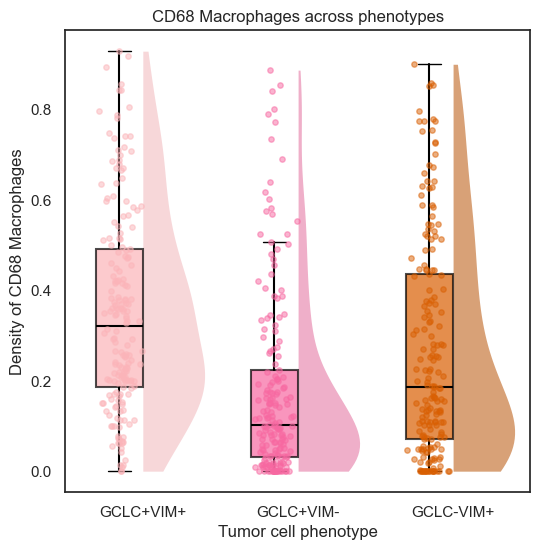

In [17]:
# Set up plot
fig, ax = plt.subplots(figsize=figsize)

# Convert group names to x-axis positions
xpos = np.arange(len(group_order))

# Violin plot (right half only)
sns.violinplot(data=df_melt, x="Cell_Type", y="Density",
                order=group_order, palette=palette, alpha=0.6,
                cut=0, scale="width", inner=None, linewidth=0, ax=ax)

# Clip left half of violin to simulate half violin
for collection in ax.collections:
    path = collection.get_paths()[0]
    vertices = path.vertices
    vertices[:, 0] = np.clip(vertices[:, 0], vertices[:, 0].mean(), None)

# Strip plot and boxplot on left side
for i, group in enumerate(group_order):
    sub_data = df_melt[df_melt["Cell_Type"] == group]
    x_left = xpos[i] - box_offset

    # Stripplot (scatter) on left
    jittered_x = np.random.normal(x_left, 0.05, size=len(sub_data))
    ax.scatter(jittered_x,
                sub_data["Density"],
                color=palette_dot[i], alpha=0.5, s=15, zorder=3)
    
    # Add boxplot on left side
    boxprops = dict(facecolor=palette[i], alpha=0.7, linewidth=1.5)
    whiskerprops = dict(linewidth=1.5)
    medianprops = dict(color='black', linewidth=1.5)
    
    # Create boxplot at the left position
    ax.boxplot([sub_data["Density"]], positions=[x_left], 
                widths=0.3, patch_artist=True,
                boxprops=boxprops, whiskerprops=whiskerprops,
                medianprops=medianprops, showfliers=False)
    
# Customize axes
ax.set_xticks(xpos)
ax.set_xticklabels(group_order)
ax.set_xlim(-0.5, len(group_order) - 0.5)
ax.set_ylabel(f"Density of {immune_cell.replace('_', ' ')}")
ax.set_xlabel("Tumor cell phenotype")
plt.title(f"{immune_cell.replace('_', ' ')} across phenotypes")

In [28]:
# Statistical annotations
y_max = df_melt["Density"].max()
comparisons = [(group_order[i], group_order[j]) for i in range(len(group_order)) for j in range(i + 1, len(group_order))]
for i, (g1, g2) in enumerate(comparisons):
    print(g1, g2),
    v1 = df_melt[df_melt["Cell_Type"] == g1]["Density"]
    v2 = df_melt[df_melt["Cell_Type"] == g2]["Density"]
    stat, p = wilcoxon(v1, v2, alternative='two-sided')
    print(stat, p)
    x1, x2 = xpos[group_order.index(g1)], xpos[group_order.index(g2)]
    y = y_max + (i + 1) * 0.05
    ax.plot([x1, x1, x2, x2], [y, y + 0.01, y + 0.01, y], lw=1.5, c='k')
    ax.text((x1 + x2) / 2, y + 0.012, f"p = {p:.2e}", ha='center', va='bottom')

GCLC+VIM+ GCLC+VIM-
2256.0 5.389409032472621e-18
GCLC+VIM+ GCLC-VIM+
4603.0 6.642269698016992e-08
GCLC+VIM- GCLC-VIM+
6064.0 0.0010361064366085282


In [38]:
df_melt

,Cell_Type,Density
0,GCLC+VIM+,0.225589
1,GCLC+VIM+,0.063187
2,GCLC+VIM+,0.105342
3,GCLC+VIM+,0.258879
4,GCLC+VIM+,0.200782
...,...,...
553,GCLC-VIM+,0.085847
554,GCLC-VIM+,0.089463
555,GCLC-VIM+,0.030303
556,GCLC-VIM+,0.154605


In [40]:
test_1 = df_melt[df_melt["Cell_Type"] == "GCLC-VIM+"]
test_1

,Cell_Type,Density
372,GCLC-VIM+,0.078757
373,GCLC-VIM+,0.048891
374,GCLC-VIM+,0.093361
375,GCLC-VIM+,0.164867
376,GCLC-VIM+,0.049395
...,...,...
553,GCLC-VIM+,0.085847
554,GCLC-VIM+,0.089463
555,GCLC-VIM+,0.030303
556,GCLC-VIM+,0.154605


In [33]:
v2

372    0.078757
373    0.048891
374    0.093361
375    0.164867
376    0.049395
         ...   
553    0.085847
554    0.089463
555    0.030303
556    0.154605
557    0.000000
Name: Density, Length: 186, dtype: float64

In [32]:
v1

186    0.218430
187    0.011034
188    0.162881
189    0.261162
190    0.000000
         ...   
367    0.224949
368    0.735170
369    0.076471
370    0.100694
371    0.063247
Name: Density, Length: 186, dtype: float64

In [46]:
diff = v1.values - v2.values
diff

array([ 0.13967245, -0.03785659,  0.06952056,  0.09629516, -0.04939542,
        0.05938138,  0.05292676,  0.04769133,  0.04398552, -0.03373731,
        0.15874813,  0.0675699 ,  0.01602906, -0.1775724 , -0.04461604,
        0.        ,  0.02320186, -0.04008461,  0.00139179,  0.81336657,
       -0.03662076,  0.11668856, -0.04222242,  0.19372932,  0.0369798 ,
       -0.03275862, -0.02006689,  0.00107759,  0.76485963, -0.05940146,
        0.00818152, -0.16240008,  0.56565882,  0.01294219, -0.10456552,
        0.04062289, -0.04738135,  0.27462963,  0.12032733, -0.034626  ,
       -0.01011905,  0.13482413,  0.12883908,  0.31342917, -0.25817388,
        0.30267341,  0.34061337,  0.82128732, -0.03535636, -0.06610863,
       -0.0112575 , -0.11565358,  0.36199729,  0.38797561,  0.19354141,
        0.09019255,  0.57236212,  0.2978777 ,  0.15487785,  0.67131933,
        0.31524837,  0.2039114 ,  0.48155454,  0.77064154,  0.72935897,
        0.55423729,  0.79284648,  0.61428408, -0.64454242, -0.35

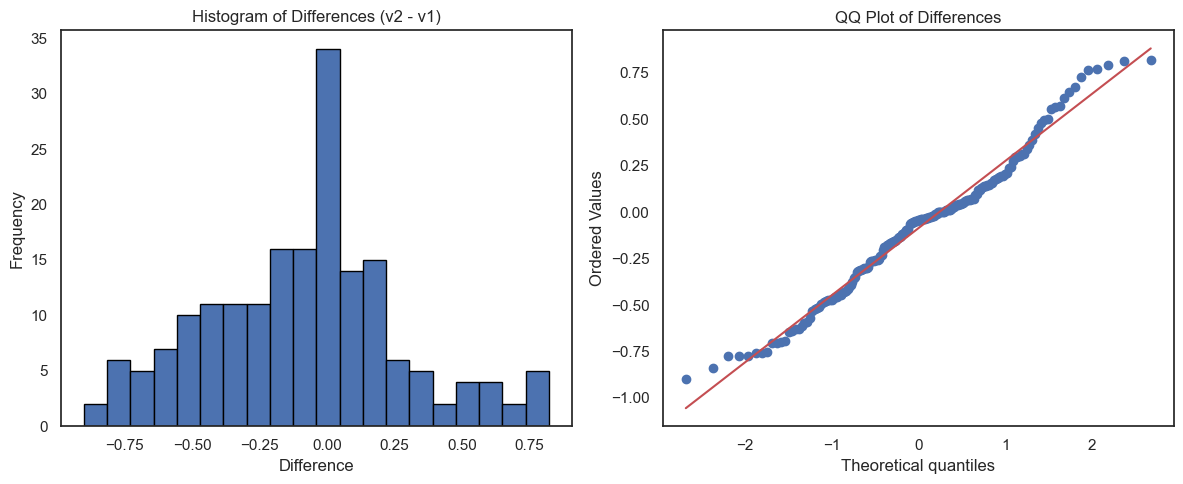

Shapiro-Wilk 检验 p 值: 0.01444
❌ 差值不服从正态分布，建议使用 Wilcoxon signed-rank test。


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 左图：直方图
axs[0].hist(diff, bins=20, edgecolor='black')
axs[0].set_title("Histogram of Differences (v2 - v1)")
axs[0].set_xlabel("Difference")
axs[0].set_ylabel("Frequency")

# 右图：QQ Plot
stats.probplot(diff, dist="norm", plot=axs[1])
axs[1].set_title("QQ Plot of Differences")

plt.tight_layout()
plt.show()

# 3. 正态性检验（Shapiro-Wilk）
stat, p = stats.shapiro(diff)
print(f"Shapiro-Wilk 检验 p 值: {p:.5f}")
if p > 0.05:
    print("✅ 差值近似正态分布，可使用 paired t-test。")
else:
    print("❌ 差值不服从正态分布，建议使用 Wilcoxon signed-rank test。")